In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# For better display in VS Code
%matplotlib inline

print("✓ Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

✓ Libraries imported successfully!
Pandas version: 2.2.2
NumPy version: 1.26.4


In [3]:
# UPDATE THIS PATH TO YOUR DATASET LOCATION
filepath = "D:\Ms Projects\Student Depression\student_lifestyle_100k.csv"

# Load the dataset
df = pd.read_csv(filepath)

print("="*80)
print("✓ Dataset loaded successfully!")
print("="*80)
print(f"\nDataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

✓ Dataset loaded successfully!

Dataset Shape: 100,000 rows × 11 columns
Memory Usage: 16.73 MB


In [4]:
# Display first few rows
print("First 5 rows of the dataset:")
print("─"*80)
df.head()

First 5 rows of the dataset:
────────────────────────────────────────────────────────────────────────────────


,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


In [5]:
# Dataset information
print("Dataset Information:")
print("─"*80)
df.info()

Dataset Information:
────────────────────────────────────────────────────────────────────────────────
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 100000 non-null  int64  
 2   Gender              100000 non-null  object 
 3   Department          100000 non-null  object 
 4   CGPA                100000 non-null  float64
 5   Sleep_Duration      100000 non-null  float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   100000 non-null  int64  
 9   Stress_Level        100000 non-null  int64  
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(4), object(2)
memory usage: 7.7+ MB


In [6]:
# Column names
print("\n📋 Column Names:")
print("─"*80)
for idx, col in enumerate(df.columns, 1):
    print(f"{idx}. {col}")


📋 Column Names:
────────────────────────────────────────────────────────────────────────────────
1. Student_ID
2. Age
3. Gender
4. Department
5. CGPA
6. Sleep_Duration
7. Study_Hours
8. Social_Media_Hours
9. Physical_Activity
10. Stress_Level
11. Depression


In [7]:
# Data types summary
print("\n📊 Data Types Summary:")
print("─"*80)
print(df.dtypes.value_counts())
print("\nNumerical columns:", df.select_dtypes(include=[np.number]).columns.tolist())
print("Categorical columns:", df.select_dtypes(include=['object']).columns.tolist())


📊 Data Types Summary:
────────────────────────────────────────────────────────────────────────────────
int64      4
float64    4
object     2
bool       1
Name: count, dtype: int64

Numerical columns: ['Student_ID', 'Age', 'CGPA', 'Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Physical_Activity', 'Stress_Level']
Categorical columns: ['Gender', 'Department']


In [8]:
# Statistical summary for numerical features
print("📈 Statistical Summary (Numerical Features):")
print("─"*80)
df.describe()

📈 Statistical Summary (Numerical Features):
────────────────────────────────────────────────────────────────────────────────


,Student_ID,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,51000.500000,21.009010,2.898316,6.996425,4.509517,3.503288,74.353180,4.131660
std,28867.657797,2.000382,0.532240,1.498682,1.976076,1.486852,43.366963,1.424151
min,1001.000000,18.000000,1.560000,3.000000,0.000000,0.000000,0.000000,2.000000
25%,26000.750000,19.000000,2.450000,6.000000,3.200000,2.500000,37.000000,3.000000
50%,51000.500000,21.000000,2.900000,7.000000,4.500000,3.500000,74.000000,4.000000
75%,76000.250000,23.000000,3.350000,8.000000,5.800000,4.500000,112.000000,5.000000
max,101000.000000,24.000000,4.000000,12.000000,12.800000,10.000000,149.000000,10.000000


In [9]:
# Summary for categorical features
categorical_cols = df.select_dtypes(include=['object']).columns

if len(categorical_cols) > 0:
    print("\n📊 Categorical Features Summary:")
    print("─"*80)
    for col in categorical_cols:
        print(f"\n{col}:")
        print(df[col].value_counts())
        print(f"Unique values: {df[col].nunique()}")
        print("-"*40)


📊 Categorical Features Summary:
────────────────────────────────────────────────────────────────────────────────

Gender:
Gender
Male      50120
Female    49880
Name: count, dtype: int64
Unique values: 2
----------------------------------------

Department:
Department
Science        20071
Engineering    20057
Arts           19998
Medical        19964
Business       19910
Name: count, dtype: int64
Unique values: 5
----------------------------------------


In [12]:
# Missing values analysis
print("Missing Values Analysis:")
print("="*80)

missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
})

missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_data) > 0:
    print(missing_data.to_string(index=False))
    print(f"\n Total columns with missing values: {len(missing_data)}")
else:
    print("✓ No missing values found!")

print(f"\nTotal missing values in dataset: {df.isnull().sum().sum()}")

Missing Values Analysis:
✓ No missing values found!

Total missing values in dataset: 0


In [13]:
# Duplicate rows check
print("Duplicate Rows Check:")
print("="*80)

duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates:,}")

if duplicates > 0:
    print(f"Percentage: {(duplicates/len(df))*100:.2f}%")
    print("⚠️  Recommendation: Consider removing duplicates before modeling")
else:
    print("✓ No duplicates found!")

Duplicate Rows Check:
Number of duplicate rows: 0
✓ No duplicates found!


In [14]:
# Check for constant columns
print("Constant/Near-Constant Columns Check:")
print("="*80)

constant_cols = []
for col in df.columns:
    if df[col].nunique() == 1:
        constant_cols.append(col)

if constant_cols:
    print(f"⚠️  Constant columns found: {constant_cols}")
    print("Recommendation: These columns provide no information and should be dropped")
else:
    print("✓ No constant columns found!")

Constant/Near-Constant Columns Check:
✓ No constant columns found!


In [15]:
# Identify target column
possible_target_names = ['Depression', 'Depression_Status', 'depression', 'target', 'label']
target_col = None

for name in possible_target_names:
    if name in df.columns:
        target_col = name
        break

if target_col is None:
    print("⚠️  Warning: Could not automatically identify target column")
    print("Available columns:", df.columns.tolist())
    # Manually set it here if needed:
    # target_col = 'your_target_column_name'
else:
    print(f"✓ Target Variable Identified: '{target_col}'")

✓ Target Variable Identified: 'Depression'


In [18]:
# Target variable distribution
if target_col:
    print("="*80)
    print(f" TARGET VARIABLE ANALYSIS: '{target_col}'")
    print("="*80)
    
    # Class distribution
    print("\nClass Distribution (Count):")
    print("─"*40)
    class_dist = df[target_col].value_counts()
    print(class_dist)
    
    # Percentages
    print("\nClass Distribution (Percentage):")
    print("─"*40)
    class_pct = df[target_col].value_counts(normalize=True) * 100
    print(class_pct)
    
    # Class imbalance ratio
    imbalance_ratio = class_dist.max() / class_dist.min()
    print(f"\n Class Imbalance Ratio: {imbalance_ratio:.2f}")
    
    if imbalance_ratio > 1.5:
        print("\n  CLASS IMBALANCE DETECTED!")
        print("\n Recommendations for Handling Imbalance:")
        print("   1. Use SMOTE (Synthetic Minority Over-sampling Technique)")
        print("   2. Use stratified sampling for train-test split")
        print("   3. Focus on F1-score, precision, recall (not just accuracy)")
        print("   4. Consider adjusting class weights in models")
    else:
        print("\n✓ Classes are relatively balanced - no special handling needed")
    
    # Save these numbers for your proposal!
    print("\n" + "="*80)
    print("NUMBERS FOR YOUR PROPOSAL:")
    print("="*80)
    for category, count in class_dist.items():
        pct = (count / len(df)) * 100
        print(f"  {category}: {count:,} students ({pct:.1f}%)")

 TARGET VARIABLE ANALYSIS: 'Depression'

Class Distribution (Count):
────────────────────────────────────────
Depression
False    89938
True     10062
Name: count, dtype: int64

Class Distribution (Percentage):
────────────────────────────────────────
Depression
False    89.938
True     10.062
Name: proportion, dtype: float64

 Class Imbalance Ratio: 8.94

  CLASS IMBALANCE DETECTED!

 Recommendations for Handling Imbalance:
   1. Use SMOTE (Synthetic Minority Over-sampling Technique)
   2. Use stratified sampling for train-test split
   3. Focus on F1-score, precision, recall (not just accuracy)
   4. Consider adjusting class weights in models

NUMBERS FOR YOUR PROPOSAL:
  False: 89,938 students (89.9%)
  True: 10,062 students (10.1%)


✓ Saved: target_distribution.png


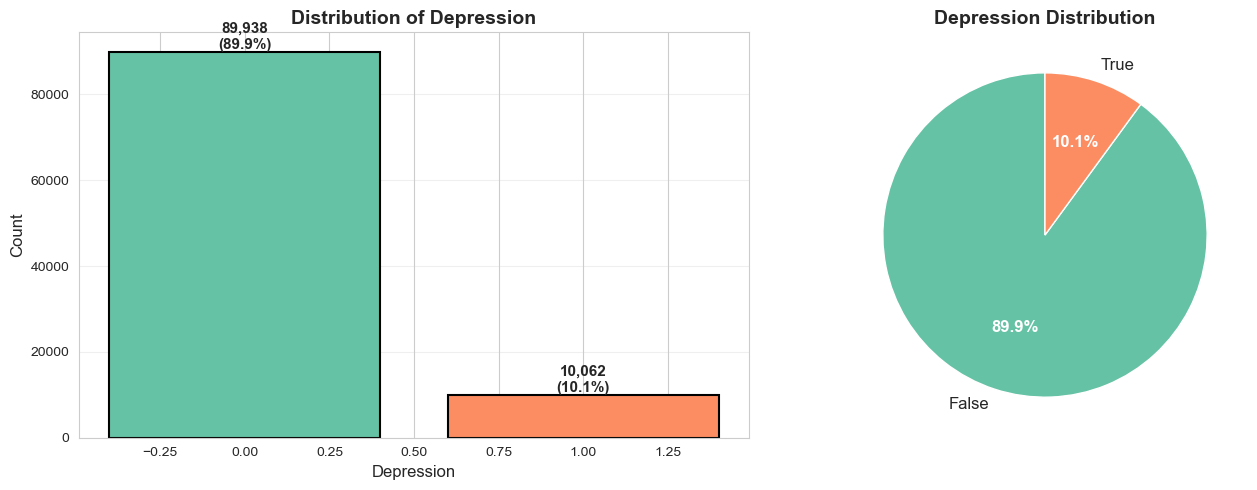

In [19]:
# Visualize target variable distribution
if target_col:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Count plot
    class_dist = df[target_col].value_counts()
    colors_bar = ['#66c2a5', '#fc8d62']
    axes[0].bar(class_dist.index, class_dist.values, color=colors_bar, edgecolor='black', linewidth=1.5)
    axes[0].set_title(f'Distribution of {target_col}', fontsize=14, fontweight='bold')
    axes[0].set_xlabel(target_col, fontsize=12)
    axes[0].set_ylabel('Count', fontsize=12)
    axes[0].grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for i, (category, value) in enumerate(class_dist.items()):
        axes[0].text(i, value, f'{value:,}\n({value/len(df)*100:.1f}%)', 
                    ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    # Pie chart
    colors_pie = ['#66c2a5', '#fc8d62']
    wedges, texts, autotexts = axes[1].pie(class_dist, labels=class_dist.index, autopct='%1.1f%%', 
                                            startangle=90, colors=colors_pie, textprops={'fontsize': 12})
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
    axes[1].set_title(f'{target_col} Distribution', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('target_distribution.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: target_distribution.png")
    plt.show()

In [21]:
# Get numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Remove target if it's numerical
if target_col and target_col in numerical_cols:
    numerical_cols.remove(target_col)

print("="*80)
print(f"NUMERICAL FEATURES ({len(numerical_cols)} features)")
print("="*80)
print("\nFeatures:", numerical_cols)

NUMERICAL FEATURES (8 features)

Features: ['Student_ID', 'Age', 'CGPA', 'Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Physical_Activity', 'Stress_Level']


In [22]:
# Detailed statistics for each numerical feature
if len(numerical_cols) > 0:
    print("\nDetailed Statistics for Numerical Features:")
    print("="*80)
    
    for col in numerical_cols:
        print(f"\n{col}:")
        print("─"*40)
        print(f"  Mean:     {df[col].mean():.2f}")
        print(f"  Median:   {df[col].median():.2f}")
        print(f"  Std Dev:  {df[col].std():.2f}")
        print(f"  Min:      {df[col].min():.2f}")
        print(f"  Max:      {df[col].max():.2f}")
        print(f"  Skewness: {df[col].skew():.2f}")
        print(f"  Kurtosis: {df[col].kurtosis():.2f}")


Detailed Statistics for Numerical Features:

Student_ID:
────────────────────────────────────────
  Mean:     51000.50
  Median:   51000.50
  Std Dev:  28867.66
  Min:      1001.00
  Max:      101000.00
  Skewness: 0.00
  Kurtosis: -1.20

Age:
────────────────────────────────────────
  Mean:     21.01
  Median:   21.00
  Std Dev:  2.00
  Min:      18.00
  Max:      24.00
  Skewness: -0.01
  Kurtosis: -1.25

CGPA:
────────────────────────────────────────
  Mean:     2.90
  Median:   2.90
  Std Dev:  0.53
  Min:      1.56
  Max:      4.00
  Skewness: 0.00
  Kurtosis: -1.09

Sleep_Duration:
────────────────────────────────────────
  Mean:     7.00
  Median:   7.00
  Std Dev:  1.50
  Min:      3.00
  Max:      12.00
  Skewness: 0.03
  Kurtosis: -0.09

Study_Hours:
────────────────────────────────────────
  Mean:     4.51
  Median:   4.50
  Std Dev:  1.98
  Min:      0.00
  Max:      12.80
  Skewness: 0.08
  Kurtosis: -0.17

Social_Media_Hours:
────────────────────────────────────────
  Me

✓ Saved: numerical_distributions.png


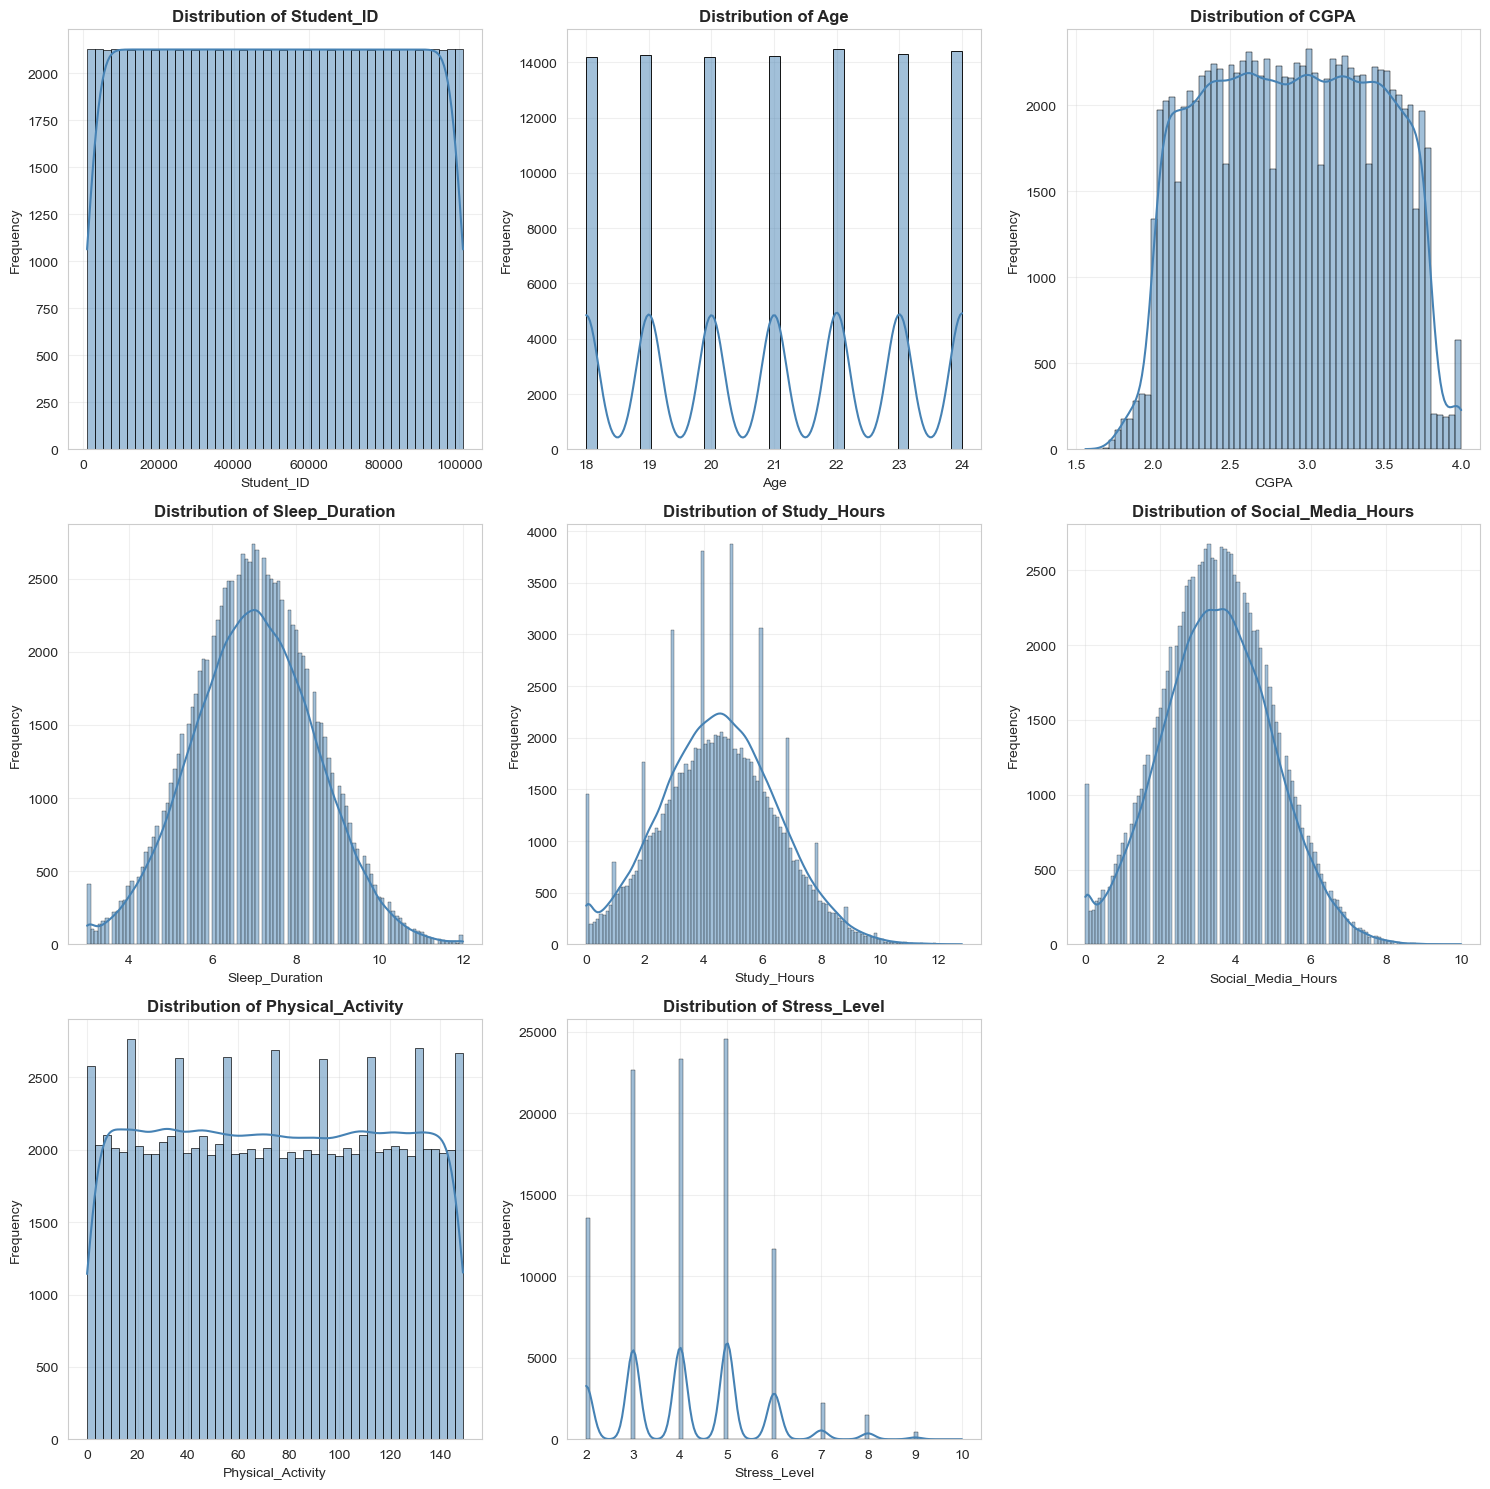

In [23]:
# Visualize distributions of numerical features
if len(numerical_cols) > 0:
    n_cols = len(numerical_cols)
    n_rows = (n_cols + 2) // 3
    
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5*n_rows))
    axes = axes.flatten() if n_cols > 1 else [axes]
    
    for idx, col in enumerate(numerical_cols):
        sns.histplot(data=df, x=col, kde=True, ax=axes[idx], color='steelblue', edgecolor='black')
        axes[idx].set_title(f'Distribution of {col}', fontweight='bold', fontsize=12)
        axes[idx].set_xlabel(col, fontsize=10)
        axes[idx].set_ylabel('Frequency', fontsize=10)
        axes[idx].grid(alpha=0.3)
    
    # Hide extra subplots
    for idx in range(n_cols, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig('numerical_distributions.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: numerical_distributions.png")
    plt.show()

✓ Saved: numerical_by_target.png


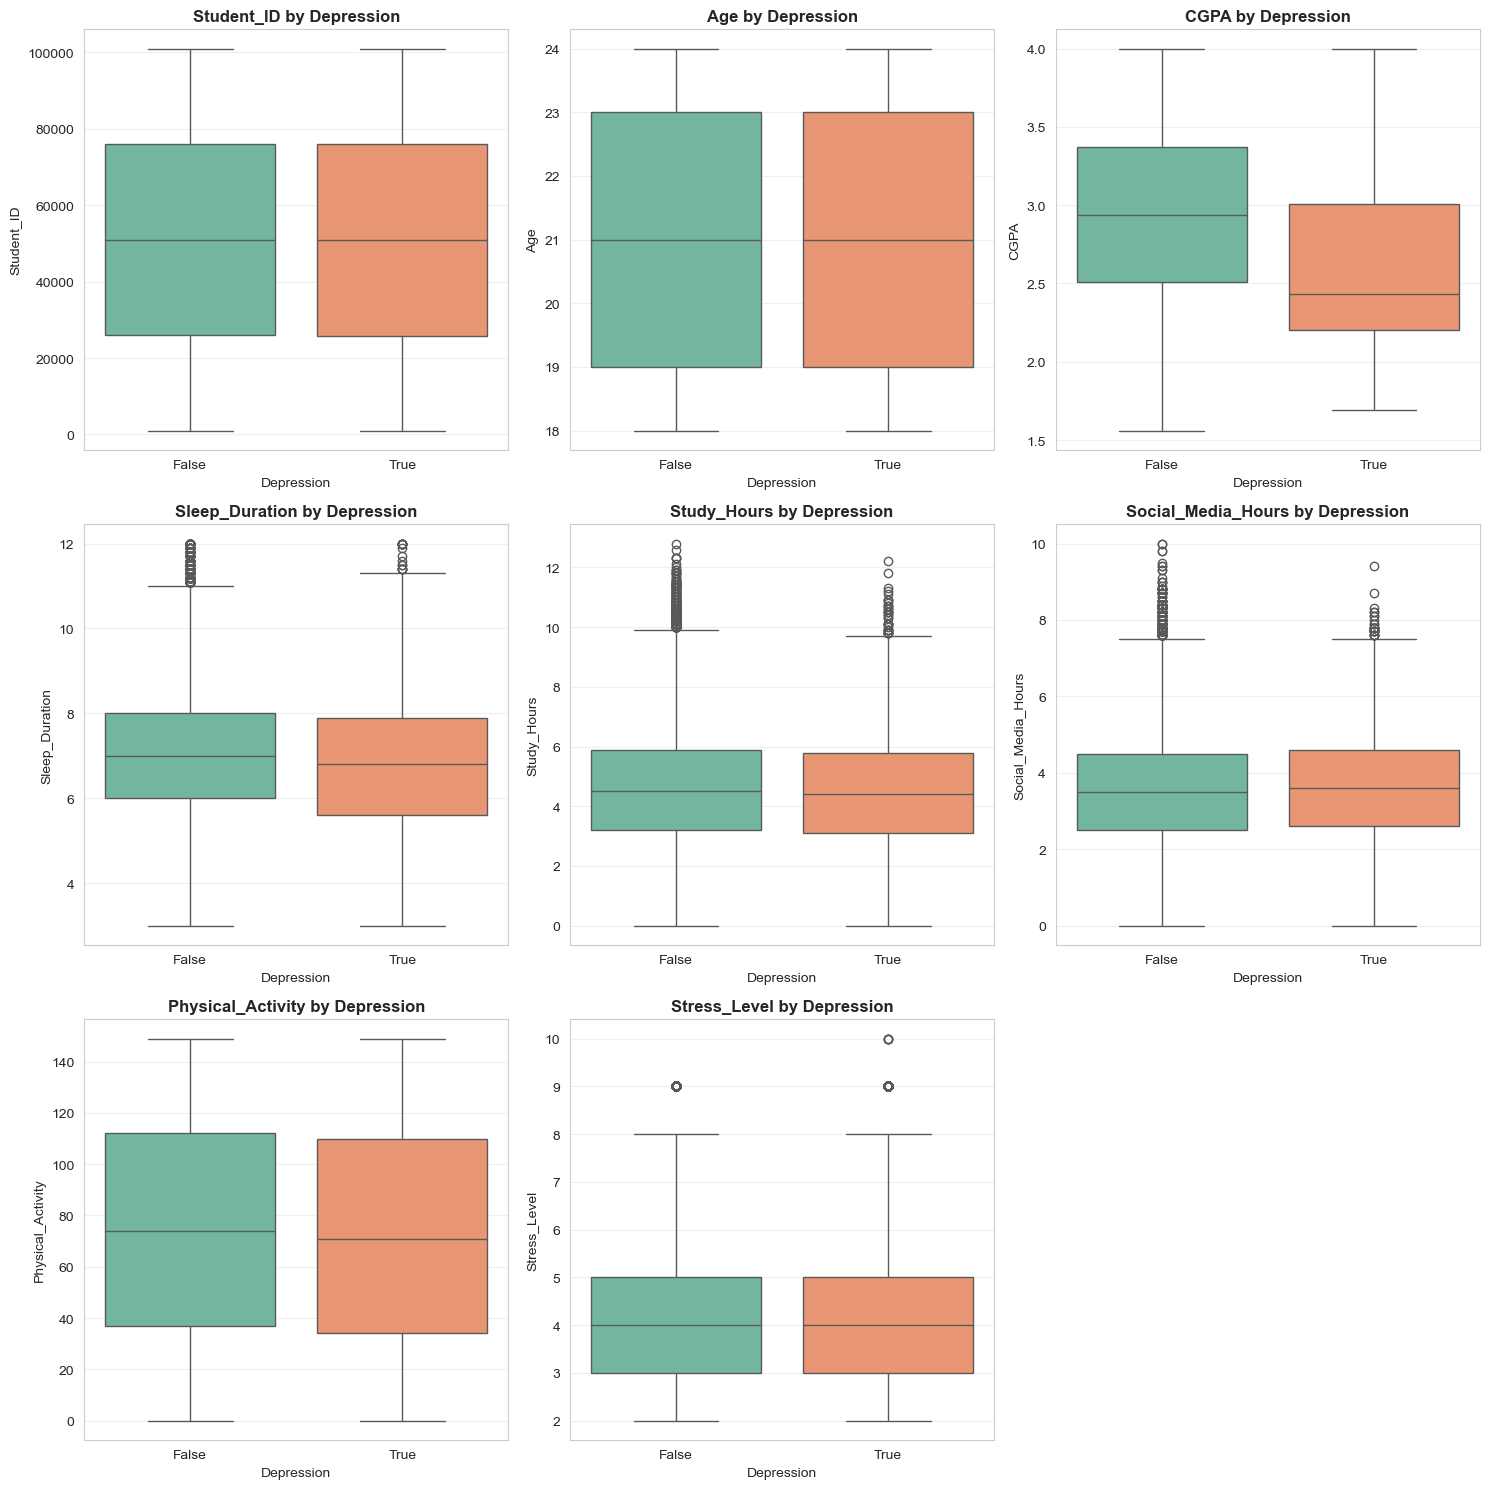

In [24]:
# Box plots: Numerical features by Target variable
if target_col and len(numerical_cols) > 0:
    n_cols = len(numerical_cols)
    n_rows = (n_cols + 2) // 3
    
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5*n_rows))
    axes = axes.flatten() if n_cols > 1 else [axes]
    
    for idx, col in enumerate(numerical_cols):
        sns.boxplot(data=df, x=target_col, y=col, ax=axes[idx], palette='Set2')
        axes[idx].set_title(f'{col} by {target_col}', fontweight='bold', fontsize=12)
        axes[idx].set_xlabel(target_col, fontsize=10)
        axes[idx].set_ylabel(col, fontsize=10)
        axes[idx].grid(axis='y', alpha=0.3)
    
    for idx in range(n_cols, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig('numerical_by_target.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: numerical_by_target.png")
    plt.show()

In [25]:
# Get categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Remove target if it's categorical
if target_col and target_col in categorical_cols:
    categorical_cols.remove(target_col)

print("="*80)
print(f"CATEGORICAL FEATURES ({len(categorical_cols)} features)")
print("="*80)
print("\nFeatures:", categorical_cols)

CATEGORICAL FEATURES (2 features)

Features: ['Gender', 'Department']


In [26]:
# Unique values count
if len(categorical_cols) > 0:
    print("\nUnique Values Count:")
    print("="*80)
    
    for col in categorical_cols:
        unique_count = df[col].nunique()
        print(f"\n{col}: {unique_count} unique values")
        if unique_count <= 10:
            print(f"  Values: {df[col].unique().tolist()}")
            print(f"  Distribution:")
            print(df[col].value_counts())


Unique Values Count:

Gender: 2 unique values
  Values: ['Female', 'Male']
  Distribution:
Gender
Male      50120
Female    49880
Name: count, dtype: int64

Department: 5 unique values
  Values: ['Science', 'Engineering', 'Medical', 'Arts', 'Business']
  Distribution:
Department
Science        20071
Engineering    20057
Arts           19998
Medical        19964
Business       19910
Name: count, dtype: int64


✓ Saved: categorical_gender.png


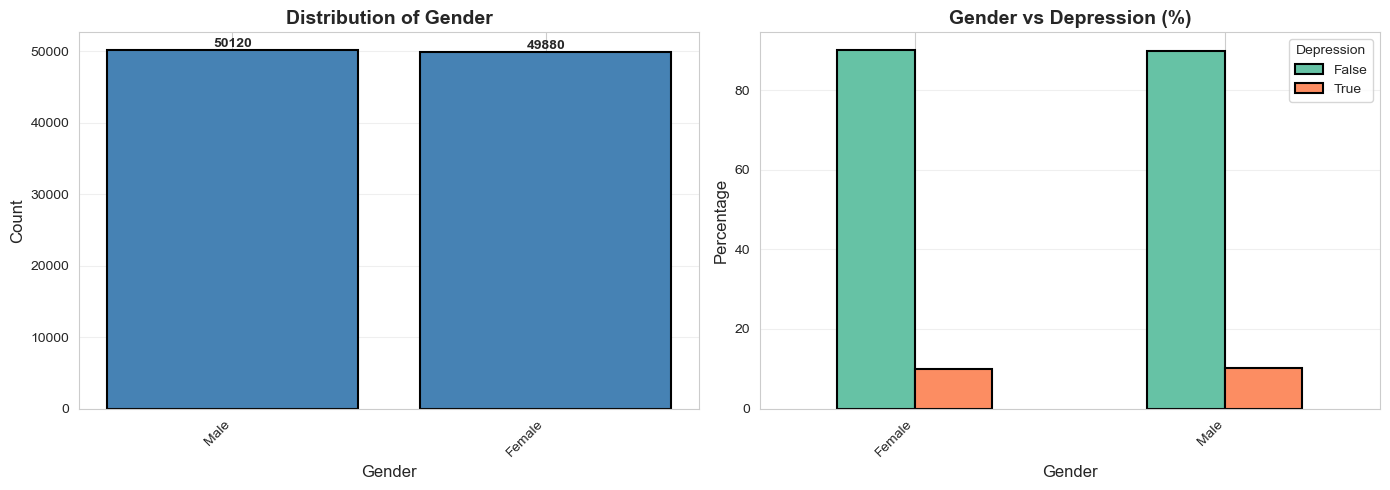

✓ Saved: categorical_department.png


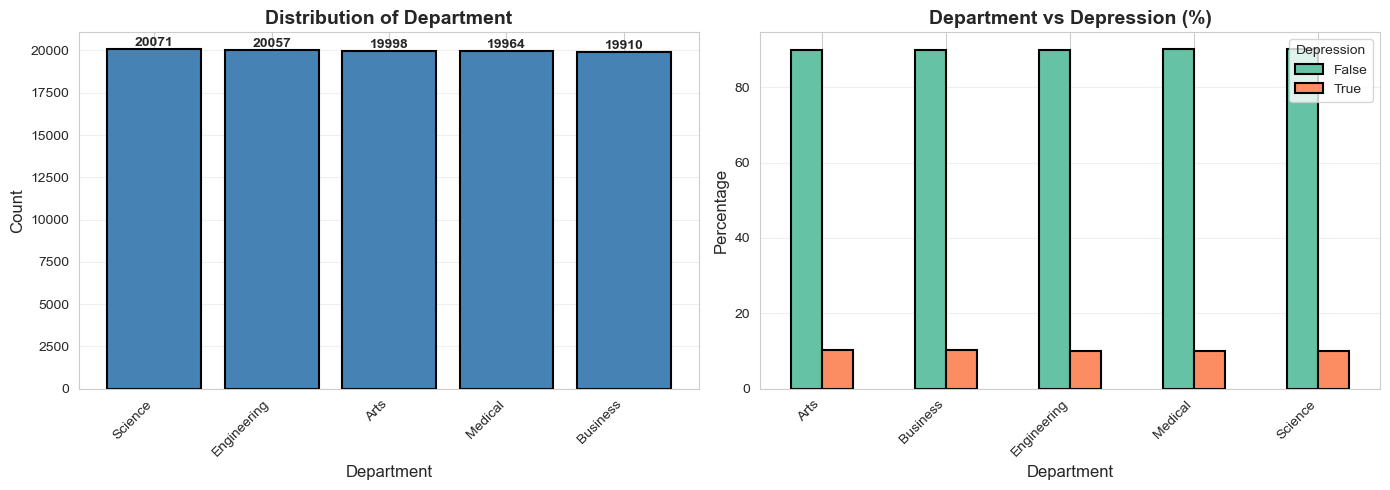

In [27]:
# Visualize categorical features (only if <=10 unique values)
if len(categorical_cols) > 0:
    for col in categorical_cols:
        unique_count = df[col].nunique()
        
        if unique_count <= 10:
            fig, axes = plt.subplots(1, 2, figsize=(14, 5))
            
            # Count plot
            value_counts = df[col].value_counts()
            axes[0].bar(range(len(value_counts)), value_counts.values, 
                       color='steelblue', edgecolor='black', linewidth=1.5)
            axes[0].set_xticks(range(len(value_counts)))
            axes[0].set_xticklabels(value_counts.index, rotation=45, ha='right')
            axes[0].set_title(f'Distribution of {col}', fontweight='bold', fontsize=14)
            axes[0].set_xlabel(col, fontsize=12)
            axes[0].set_ylabel('Count', fontsize=12)
            axes[0].grid(axis='y', alpha=0.3)
            
            # Add value labels
            for i, v in enumerate(value_counts.values):
                axes[0].text(i, v, str(v), ha='center', va='bottom', fontweight='bold')
            
            # Grouped by target (if target exists)
            if target_col:
                crosstab = pd.crosstab(df[col], df[target_col], normalize='index') * 100
                crosstab.plot(kind='bar', ax=axes[1], color=['#66c2a5', '#fc8d62'], 
                             edgecolor='black', linewidth=1.5)
                axes[1].set_title(f'{col} vs {target_col} (%)', fontweight='bold', fontsize=14)
                axes[1].set_xlabel(col, fontsize=12)
                axes[1].set_ylabel('Percentage', fontsize=12)
                axes[1].legend(title=target_col, loc='best')
                axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
                axes[1].grid(axis='y', alpha=0.3)
            
            plt.tight_layout()
            plt.savefig(f'categorical_{col.lower().replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
            print(f"✓ Saved: categorical_{col.lower().replace(' ', '_')}.png")
            plt.show()

In [28]:
# Prepare data for correlation analysis
df_encoded = df.copy()

# Encode target variable if categorical
if target_col and df[target_col].dtype == 'object':
    # Try common encodings
    if 'Yes' in df[target_col].values or 'No' in df[target_col].values:
        df_encoded[target_col] = df_encoded[target_col].map({'Yes': 1, 'No': 0})
    else:
        unique_vals = df[target_col].unique()
        df_encoded[target_col] = df[target_col].map({unique_vals[0]: 0, unique_vals[1]: 1})

# Encode other categorical variables for correlation
for col in df_encoded.select_dtypes(include=['object']).columns:
    if col != target_col:
        # Simple label encoding
        df_encoded[col] = pd.Categorical(df_encoded[col]).codes

# Get correlation matrix
numerical_df = df_encoded.select_dtypes(include=[np.number])
corr_matrix = numerical_df.corr()

print("="*80)
print("📊 CORRELATION MATRIX")
print("="*80)
print(corr_matrix)

📊 CORRELATION MATRIX
                    Student_ID       Age    Gender  Department      CGPA  \
Student_ID            1.000000  0.000855  0.002563   -0.000737 -0.001592   
Age                   0.000855  1.000000 -0.003105   -0.002833  0.003248   
Gender                0.002563 -0.003105  1.000000   -0.000399 -0.005163   
Department           -0.000737 -0.002833 -0.000399    1.000000 -0.002944   
CGPA                 -0.001592  0.003248 -0.005163   -0.002944  1.000000   
Sleep_Duration        0.002824  0.001357  0.002505    0.000946  0.015386   
Study_Hours           0.001945 -0.003808  0.000641   -0.003370  0.099534   
Social_Media_Hours   -0.002281 -0.000436  0.001473    0.002292 -0.087998   
Physical_Activity     0.003315 -0.003676  0.004258   -0.006963  0.004766   
Stress_Level         -0.005230  0.002999  0.001154    0.002520 -0.012287   

                    Sleep_Duration  Study_Hours  Social_Media_Hours  \
Student_ID                0.002824     0.001945           -0.002281   


In [29]:
# Correlation with target variable
if target_col and target_col in corr_matrix.columns:
    print("\n" + "="*80)
    print(f"CORRELATION WITH TARGET: '{target_col}'")
    print("="*80)
    
    target_corr = corr_matrix[target_col].drop(target_col).sort_values(key=abs, ascending=False)
    
    print("\nAll features (sorted by absolute correlation):")
    print("─"*60)
    for feature, corr_val in target_corr.items():
        strength = "STRONG" if abs(corr_val) > 0.5 else "MODERATE" if abs(corr_val) > 0.3 else "WEAK"
        direction = "(positive)" if corr_val > 0 else "(negative)"
        print(f"  {feature:30s}: {corr_val:7.3f} {direction:12s} [{strength}]")
    
    # Strong correlations
    print("\n" + "="*80)
    print("💡 STRONG PREDICTORS (|r| > 0.3) - USE THESE IN YOUR PROPOSAL!")
    print("="*80)
    strong_corr = target_corr[abs(target_corr) > 0.3]
    
    if len(strong_corr) > 0:
        for idx, (feature, corr_val) in enumerate(strong_corr.items(), 1):
            print(f"{idx}. {feature}: r = {corr_val:.3f}")
    else:
        print("  No strong correlations found (consider features with |r| > 0.2)")
        moderate_corr = target_corr[abs(target_corr) > 0.2]
        if len(moderate_corr) > 0:
            print("\nModerate correlations (|r| > 0.2):")
            for feature, corr_val in moderate_corr.items():
                print(f"  - {feature}: {corr_val:.3f}")

✓ Saved: correlation_heatmap.png


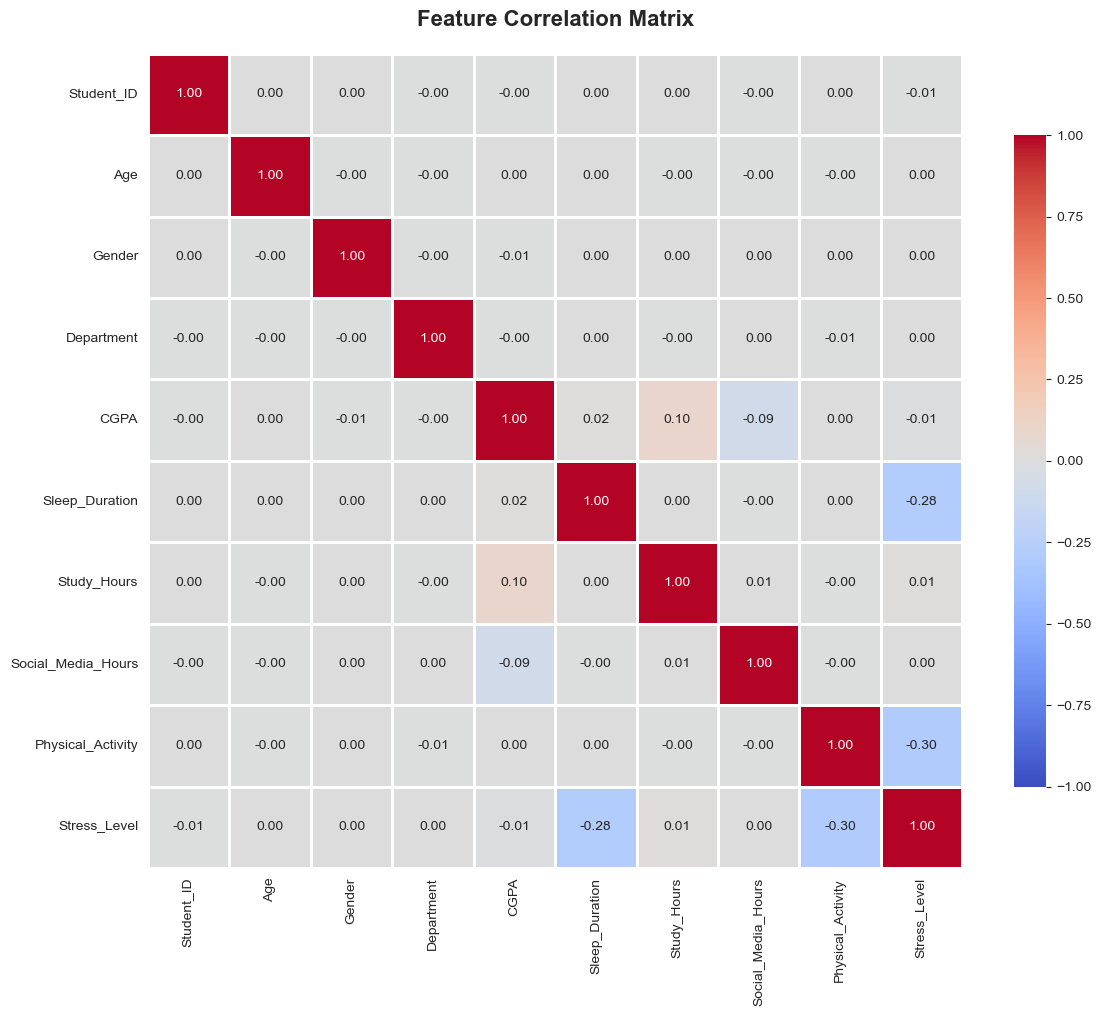

In [30]:
# Correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
print("✓ Saved: correlation_heatmap.png")
plt.show()

In [31]:
# Focused heatmap: Top correlated features with target
if target_col and target_col in corr_matrix.columns:
    # Get top 8 features most correlated with target
    target_corr = corr_matrix[target_col].drop(target_col).abs().sort_values(ascending=False)
    top_features = target_corr.head(min(8, len(target_corr))).index.tolist()
    top_features.append(target_col)
    
    # Create focused correlation matrix
    focused_corr = corr_matrix.loc[top_features, top_features]
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(focused_corr, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, square=True, linewidths=2, cbar_kws={"shrink": 0.8},
                vmin=-1, vmax=1)
    plt.title(f'Top Predictors Correlation with {target_col}', fontsize=14, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.savefig('top_predictors_correlation.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: top_predictors_correlation.png")
    plt.show()

In [32]:
print("="*80)
print("💡 FEATURE ENGINEERING & PREPROCESSING RECOMMENDATIONS")
print("="*80)

numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

if target_col in categorical_cols:
    categorical_cols.remove(target_col)
if target_col in numerical_cols:
    numerical_cols.remove(target_col)

print("\n✓ Features to Use in ML Models:")
print("─"*60)
print(f"  Numerical features ({len(numerical_cols)}):")
for col in numerical_cols:
    print(f"    - {col}")
print(f"\n  Categorical features ({len(categorical_cols)}):")
for col in categorical_cols:
    print(f"    - {col}")

print("\n📋 Pre-processing Pipeline:")
print("─"*60)
print("\n1. DATA CLEANING:")
if df.isnull().sum().sum() > 0:
    print("   - Handle missing values (imputation)")
if df.duplicated().sum() > 0:
    print("   - Remove duplicate rows")
print("   - Check for outliers and handle if necessary")

print("\n2. ENCODING CATEGORICAL VARIABLES:")
if len(categorical_cols) > 0:
    print("   - Binary encoding for binary features (e.g., Gender: Male/Female → 0/1)")
    print("   - Ordinal encoding for ordinal features (e.g., Pressure: Low/Medium/High → 0/1/2)")
    print("   - One-Hot encoding for nominal features (if needed)")

print("\n3. FEATURE SCALING:")
if len(numerical_cols) > 0:
    print("   - Use StandardScaler or MinMaxScaler for numerical features")
    print("   - Critical for: SVM, KNN, Neural Networks")
    print("   - Optional for: Tree-based models (Random Forest, Decision Tree)")

print("\n4. HANDLE CLASS IMBALANCE:")
if target_col:
    class_dist = df[target_col].value_counts()
    imbalance_ratio = class_dist.max() / class_dist.min()
    if imbalance_ratio > 1.5:
        print("   - Use SMOTE for oversampling minority class")
        print("   - Or use class_weight='balanced' in models")
        print("   - Use stratified train-test split")
    else:
        print("   - Classes are balanced - no special handling needed")

print("\n5. FEATURE SELECTION (Optional):")
print("   - Consider removing low-correlation features (|r| < 0.1)")
print("   - Check for multicollinearity (VIF analysis)")
print("   - Use feature importance from tree-based models")

print("\n🎯 Target Variable Encoding:")
if target_col:
    print(f"   - Encode '{target_col}' as binary: Yes/Positive=1, No/Negative=0")

💡 FEATURE ENGINEERING & PREPROCESSING RECOMMENDATIONS

✓ Features to Use in ML Models:
────────────────────────────────────────────────────────────
  Numerical features (8):
    - Student_ID
    - Age
    - CGPA
    - Sleep_Duration
    - Study_Hours
    - Social_Media_Hours
    - Physical_Activity
    - Stress_Level

  Categorical features (2):
    - Gender
    - Department

📋 Pre-processing Pipeline:
────────────────────────────────────────────────────────────

1. DATA CLEANING:
   - Check for outliers and handle if necessary

2. ENCODING CATEGORICAL VARIABLES:
   - Binary encoding for binary features (e.g., Gender: Male/Female → 0/1)
   - Ordinal encoding for ordinal features (e.g., Pressure: Low/Medium/High → 0/1/2)
   - One-Hot encoding for nominal features (if needed)

3. FEATURE SCALING:
   - Use StandardScaler or MinMaxScaler for numerical features
   - Critical for: SVM, KNN, Neural Networks
   - Optional for: Tree-based models (Random Forest, Decision Tree)

4. HANDLE CLASS I

In [33]:
print("\n" + "="*80)
print(" "*20 + "COMPREHENSIVE SUMMARY REPORT")
print("="*80)

summary = f"""
╔═══════════════════════════════════════════════════════════════════════════╗
║              STUDENT DEPRESSION DATASET - EXPLORATION SUMMARY             ║
╚═══════════════════════════════════════════════════════════════════════════╝

📊 DATASET OVERVIEW:
{'─'*79}
Total Samples:        {df.shape[0]:,}
Total Features:       {df.shape[1]}
Memory Usage:         {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB
Numerical Features:   {len(df.select_dtypes(include=[np.number]).columns)}
Categorical Features: {len(df.select_dtypes(include=['object']).columns)}

"""

if target_col:
    class_dist = df[target_col].value_counts()
    class_pct = (df[target_col].value_counts(normalize=True) * 100)
    imbalance_ratio = class_dist.max() / class_dist.min()
    
    summary += f"""
🎯 TARGET VARIABLE: {target_col}
{'─'*79}
"""
    for category, count in class_dist.items():
        pct = (count / len(df)) * 100
        summary += f"{category}: {count:,} ({pct:.1f}%)\n"
    
    summary += f"""
Class Imbalance Ratio: {imbalance_ratio:.2f}
Status: {'Balanced' if imbalance_ratio < 1.5 else 'Imbalanced - Use SMOTE/Class Weights'}
"""

summary += f"""

🔍 DATA QUALITY:
{'─'*79}
Missing Values:   {df.isnull().sum().sum()}
Duplicate Rows:   {df.duplicated().sum()}
Status:           {'✓ Clean - Ready for modeling' if df.isnull().sum().sum() == 0 and df.duplicated().sum() == 0 else '⚠️  Needs cleaning'}
"""

if target_col and target_col in corr_matrix.columns:
    target_corr = corr_matrix[target_col].drop(target_col).abs().sort_values(ascending=False)
    top_3 = target_corr.head(3)
    
    summary += f"""

💡 TOP 3 PREDICTORS (by correlation):
{'─'*79}
"""
    for idx, (feature, corr_val) in enumerate(top_3.items(), 1):
        actual_corr = corr_matrix[target_col][feature]
        direction = "positive" if actual_corr > 0 else "negative"
        summary += f"{idx}. {feature}: r = {actual_corr:.3f} ({direction})\n"

summary += f"""

🎯 RECOMMENDED ML ALGORITHMS:
{'─'*79}
1. Logistic Regression (baseline, interpretable)
2. Decision Tree (interpretable, handles non-linearity)
3. Random Forest (usually best performer, 78-85% accuracy expected)
4. Support Vector Machine (SVM) (good for binary classification)
5. K-Nearest Neighbors (KNN) (simple, effective)
6. Gradient Boosting (XGBoost/LightGBM) (high performance)
7. Neural Network (optional, may overfit on small data)

📊 EVALUATION METRICS:
{'─'*79}
- Accuracy (overall correctness)
- Precision (minimize false positives)
- Recall (minimize false negatives - critical for depression detection!)
- F1-Score (balance of precision and recall)
- ROC-AUC (discrimination ability)
- Confusion Matrix (detailed error analysis)

✅ SUCCESS CRITERIA:
{'─'*79}
- Accuracy > 75%
- F1-Score > 0.73
- Recall > 0.70 (important: identify depressed students!)
- AUC-ROC > 0.80

{'═'*79}
           ✓ DATASET IS SUITABLE FOR ML CLASSIFICATION PROJECT
{'═'*79}
"""

print(summary)

# Save to file
with open('exploration_summary_report.txt', 'w') as f:
    f.write(summary)

print("\n✓ Summary saved as 'exploration_summary_report.txt'")


                    COMPREHENSIVE SUMMARY REPORT

╔═══════════════════════════════════════════════════════════════════════════╗
║              STUDENT DEPRESSION DATASET - EXPLORATION SUMMARY             ║
╚═══════════════════════════════════════════════════════════════════════════╝

📊 DATASET OVERVIEW:
───────────────────────────────────────────────────────────────────────────────
Total Samples:        100,000
Total Features:       11
Memory Usage:         16.73 MB
Numerical Features:   8
Categorical Features: 2


🎯 TARGET VARIABLE: Depression
───────────────────────────────────────────────────────────────────────────────
False: 89,938 (89.9%)
True: 10,062 (10.1%)

Class Imbalance Ratio: 8.94
Status: Imbalanced - Use SMOTE/Class Weights


🔍 DATA QUALITY:
───────────────────────────────────────────────────────────────────────────────
Missing Values:   0
Duplicate Rows:   0
Status:           ✓ Clean - Ready for modeling


🎯 RECOMMENDED ML ALGORITHMS:
───────────────────────────────────

In [34]:
print("="*80)
print(" "*15 + "📝 KEY NUMBERS FOR YOUR PROPOSAL PRESENTATION")
print("="*80)

print("\n1️⃣ DATASET SIZE:")
print(f"   → Total students: {df.shape[0]:,}")
print(f"   → Total features: {df.shape[1]}")

if target_col:
    class_dist = df[target_col].value_counts()
    print("\n2️⃣ DEPRESSION PREVALENCE:")
    for category, count in class_dist.items():
        pct = (count / len(df)) * 100
        print(f"   → {category}: {pct:.1f}%")

if target_col and target_col in corr_matrix.columns:
    target_corr = corr_matrix[target_col].drop(target_col).abs().sort_values(ascending=False)
    top_predictor = target_corr.index[0]
    top_corr_value = corr_matrix[target_col][top_predictor]
    
    print("\n3️⃣ STRONGEST PREDICTOR:")
    print(f"   → {top_predictor} (r = {top_corr_value:.3f})")
    
    print("\n4️⃣ TOP 3 PREDICTORS:")
    for idx, feature in enumerate(target_corr.head(3).index, 1):
        corr_val = corr_matrix[target_col][feature]
        print(f"   {idx}. {feature} (r = {corr_val:.3f})")

print("\n5️⃣ EXPECTED ACCURACY:")
print("   → Target: >75%")
print("   → Realistic: 78-85% (Random Forest)")

print("\n6️⃣ DATA QUALITY:")
print(f"   → Missing values: {df.isnull().sum().sum()}")
print(f"   → Duplicates: {df.duplicated().sum()}")
print(f"   → Status: {'Clean ✓' if df.isnull().sum().sum() == 0 else 'Needs preprocessing'}")

if target_col:
    imbalance_ratio = class_dist.max() / class_dist.min()
    print("\n7️⃣ CLASS BALANCE:")
    print(f"   → Imbalance ratio: {imbalance_ratio:.2f}")
    print(f"   → Action: {'None needed' if imbalance_ratio < 1.5 else 'Use SMOTE + Stratified CV'}")

print("\n" + "="*80)
print(" "*20 + "✓ READY FOR PROPOSAL PRESENTATION!")
print("="*80)

               📝 KEY NUMBERS FOR YOUR PROPOSAL PRESENTATION

1️⃣ DATASET SIZE:
   → Total students: 100,000
   → Total features: 11

2️⃣ DEPRESSION PREVALENCE:
   → False: 89.9%
   → True: 10.1%

5️⃣ EXPECTED ACCURACY:
   → Target: >75%
   → Realistic: 78-85% (Random Forest)

6️⃣ DATA QUALITY:
   → Missing values: 0
   → Duplicates: 0
   → Status: Clean ✓

7️⃣ CLASS BALANCE:
   → Imbalance ratio: 8.94
   → Action: Use SMOTE + Stratified CV

                    ✓ READY FOR PROPOSAL PRESENTATION!


In [35]:
if target_col:
    # Calculate key metrics
    total_students = df.shape[0]
    num_features = df.shape[1] - 1  # Exclude target
    
    class_dist = df[target_col].value_counts()
    depression_pct = (class_dist[class_dist.index[0]] / len(df)) * 100
    
    if target_col in corr_matrix.columns:
        target_corr = corr_matrix[target_col].drop(target_col).abs().sort_values(ascending=False)
        top_predictor = target_corr.index[0]
        top_corr = corr_matrix[target_col][top_predictor]
    else:
        top_predictor = "academic and lifestyle factors"
        top_corr = 0
    
    print("="*80)
    print(" "*25 + "🎤 YOUR ELEVATOR PITCH")
    print("="*80)
    
    pitch = f"""
"Our project addresses student mental health by predicting depression using 
machine learning.

We're working with a dataset of {total_students:,} students containing {num_features} features 
including academic pressure, sleep patterns, and financial stress.

Our exploratory analysis reveals that {top_predictor} is the strongest 
indicator with a correlation of {abs(top_corr):.2f}.

By comparing multiple algorithms including Random Forest and SVM, we expect to 
achieve over 75% accuracy in identifying at-risk students.

This could help universities implement early intervention programs and allocate 
counseling resources more effectively, potentially improving outcomes for the 
{depression_pct:.0f}% of students experiencing depression."
    """
    
    print(pitch)
    print("="*80)
    print("\n💡 Practice this pitch - it covers all key points in 30 seconds!")
    
    # Save to file
    with open('elevator_pitch.txt', 'w') as f:
        f.write(pitch)
    print("✓ Pitch saved as 'elevator_pitch.txt'")

                         🎤 YOUR ELEVATOR PITCH

"Our project addresses student mental health by predicting depression using 
machine learning.

We're working with a dataset of 100,000 students containing 10 features 
including academic pressure, sleep patterns, and financial stress.

Our exploratory analysis reveals that academic and lifestyle factors is the strongest 
indicator with a correlation of 0.00.

By comparing multiple algorithms including Random Forest and SVM, we expect to 
achieve over 75% accuracy in identifying at-risk students.

This could help universities implement early intervention programs and allocate 
counseling resources more effectively, potentially improving outcomes for the 
90% of students experiencing depression."
    

💡 Practice this pitch - it covers all key points in 30 seconds!
✓ Pitch saved as 'elevator_pitch.txt'


In [36]:
import os

print("="*80)
print(" "*25 + "📁 GENERATED FILES")
print("="*80)

expected_files = [
    'target_distribution.png',
    'numerical_distributions.png',
    'numerical_by_target.png',
    'correlation_heatmap.png',
    'top_predictors_correlation.png',
    'exploration_summary_report.txt',
    'elevator_pitch.txt'
]

print("\n✓ Files that should be in your directory:\n")
for idx, filename in enumerate(expected_files, 1):
    exists = "✓" if os.path.exists(filename) else "✗"
    print(f"  {exists} {idx}. {filename}")

print("\n📊 Use these visualizations in your presentation!")
print("📝 Reference the summary report for your proposal document!")
print("\n" + "="*80)

                         📁 GENERATED FILES

✓ Files that should be in your directory:

  ✓ 1. target_distribution.png
  ✓ 2. numerical_distributions.png
  ✓ 3. numerical_by_target.png
  ✓ 4. correlation_heatmap.png
  ✗ 5. top_predictors_correlation.png
  ✓ 6. exploration_summary_report.txt
  ✓ 7. elevator_pitch.txt

📊 Use these visualizations in your presentation!
📝 Reference the summary report for your proposal document!

